In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from google.colab import files
files.upload()

Saving crime_data.csv to crime_data.csv


{'crime_data.csv': b',Murder,Assault,UrbanPop,Rape\r\nAlabama,13.2,236,58,21.2\r\nAlaska,10,263,48,44.5\r\nArizona,8.1,294,80,31\r\nArkansas,8.8,190,50,19.5\r\nCalifornia,9,276,91,40.6\r\nColorado,7.9,204,78,38.7\r\nConnecticut,3.3,110,77,11.1\r\nDelaware,5.9,238,72,15.8\r\nFlorida,15.4,335,80,31.9\r\nGeorgia,17.4,211,60,25.8\r\nHawaii,5.3,46,83,20.2\r\nIdaho,2.6,120,54,14.2\r\nIllinois,10.4,249,83,24\r\nIndiana,7.2,113,65,21\r\nIowa,2.2,56,57,11.3\r\nKansas,6,115,66,18\r\nKentucky,9.7,109,52,16.3\r\nLouisiana,15.4,249,66,22.2\r\nMaine,2.1,83,51,7.8\r\nMaryland,11.3,300,67,27.8\r\nMassachusetts,4.4,149,85,16.3\r\nMichigan,12.1,255,74,35.1\r\nMinnesota,2.7,72,66,14.9\r\nMississippi,16.1,259,44,17.1\r\nMissouri,9,178,70,28.2\r\nMontana,6,109,53,16.4\r\nNebraska,4.3,102,62,16.5\r\nNevada,12.2,252,81,46\r\nNew Hampshire,2.1,57,56,9.5\r\nNew Jersey,7.4,159,89,18.8\r\nNew Mexico,11.4,285,70,32.1\r\nNew York,11.1,254,86,26.1\r\nNorth Carolina,13,337,45,16.1\r\nNorth Dakota,0.8,45,44,7.3\r\nOh

In [13]:
df = pd.read_csv('crime_data.csv')
df

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     object 
 1   Murder      50 non-null     float64
 2   Assault     50 non-null     int64  
 3   UrbanPop    50 non-null     int64  
 4   Rape        50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [23]:
df.rename(columns = {'Unnamed: 0':'STATE'}, inplace = True)
df

,STATE,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


In [25]:
df2 = df.drop(['STATE'],axis=1)
df2

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6
5,7.9,204,78,38.7
6,3.3,110,77,11.1
7,5.9,238,72,15.8
8,15.4,335,80,31.9
9,17.4,211,60,25.8


In [28]:
# Normalize numerical data 
from sklearn.preprocessing import normalize
df_norm=pd.DataFrame(normalize(df2),columns=df2.columns)
df_norm

,Murder,Assault,UrbanPop,Rape
0,0.054031,0.966016,0.237411,0.086778
1,0.036872,0.969739,0.176987,0.164081
2,0.026439,0.959624,0.261122,0.101185
3,0.044528,0.961392,0.252998,0.098669
4,0.030657,0.940134,0.309972,0.138295
5,0.035594,0.919142,0.351437,0.174367
6,0.024486,0.816202,0.571341,0.082362
7,0.023674,0.954965,0.288897,0.063397
8,0.044478,0.967547,0.231056,0.092134
9,0.078534,0.952332,0.270805,0.116446


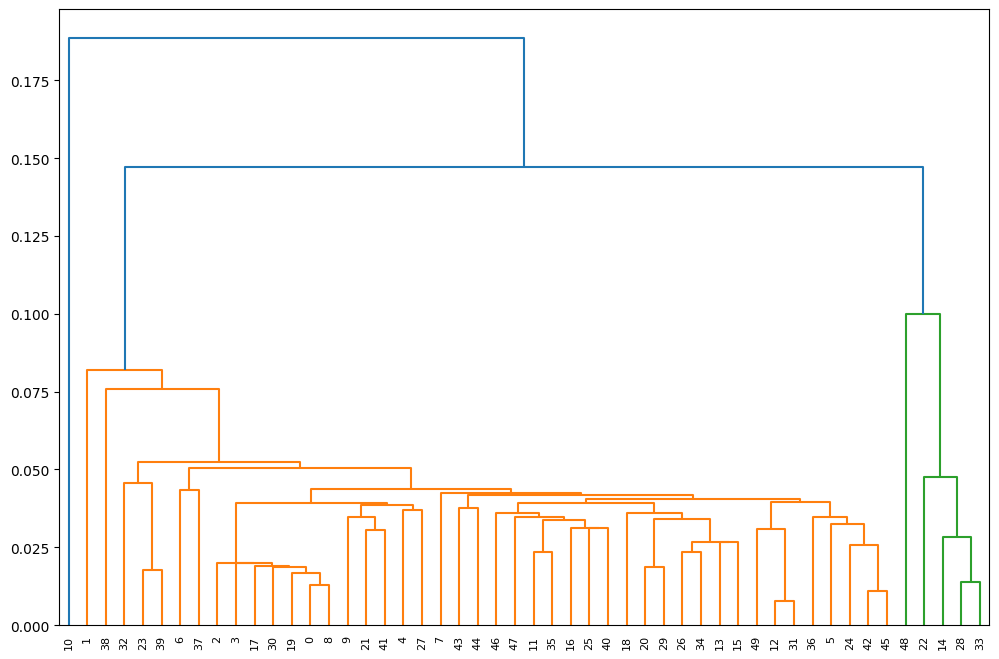

In [32]:
# Create Dendrograms
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12, 8))  
dendograms=sch.dendrogram(sch.linkage(df_norm,'single'))

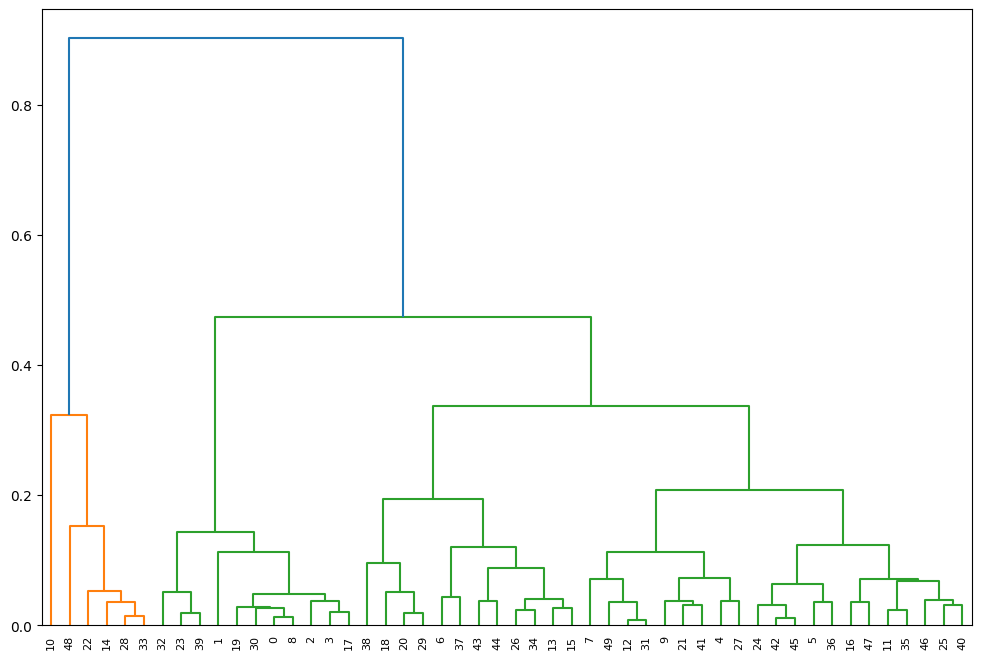

In [33]:
plt.figure(figsize=(12, 8))  
dendograms=sch.dendrogram(sch.linkage(df_norm,'complete'))

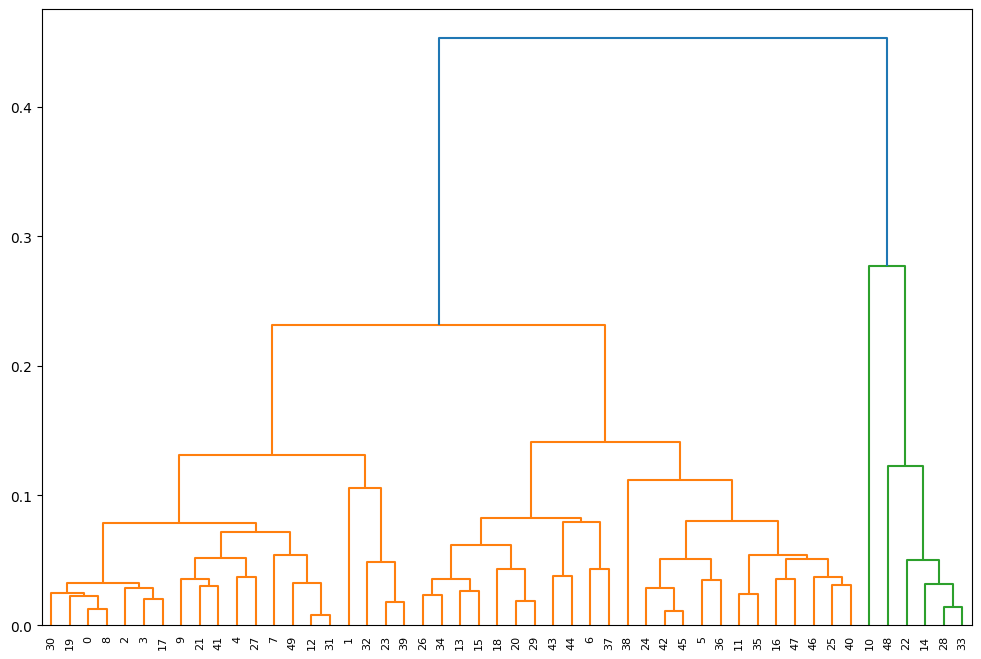

In [34]:
plt.figure(figsize=(12, 8))  
dendograms=sch.dendrogram(sch.linkage(df_norm,'average'))

In [37]:
#Creating Cluseters
from sklearn.cluster import AgglomerativeClustering
hclusters=AgglomerativeClustering(n_clusters=4,affinity='euclidean',linkage='ward')
hclusters

AgglomerativeClustering(affinity='euclidean', n_clusters=4)

In [40]:
y=pd.DataFrame(hclusters.fit_predict(df_norm),columns=['clustersid'])
y['clustersid'].value_counts()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


2    20
3    12
1    12
0     6
Name: clustersid, dtype: int64

In [42]:
# Adding clusters to dataset
df['clustersid']=hclusters.labels_
df

,STATE,Murder,Assault,UrbanPop,Rape,clustersid
0,Alabama,13.2,236,58,21.2,2
1,Alaska,10.0,263,48,44.5,2
2,Arizona,8.1,294,80,31.0,2
3,Arkansas,8.8,190,50,19.5,2
4,California,9.0,276,91,40.6,2
5,Colorado,7.9,204,78,38.7,3
6,Connecticut,3.3,110,77,11.1,1
7,Delaware,5.9,238,72,15.8,2
8,Florida,15.4,335,80,31.9,2
9,Georgia,17.4,211,60,25.8,2


In [43]:
df2.groupby('clustersid').agg(['mean']).reset_index()

,clustersid,Murder,Assault,UrbanPop,Rape
,,mean,mean,mean,mean
0,0,2.616667,54.833333,62.000000,12.333333
1,1,4.758333,116.583333,70.083333,15.683333
2,2,11.760000,255.550000,66.100000,27.090000
3,3,6.783333,141.583333,61.833333,21.466667


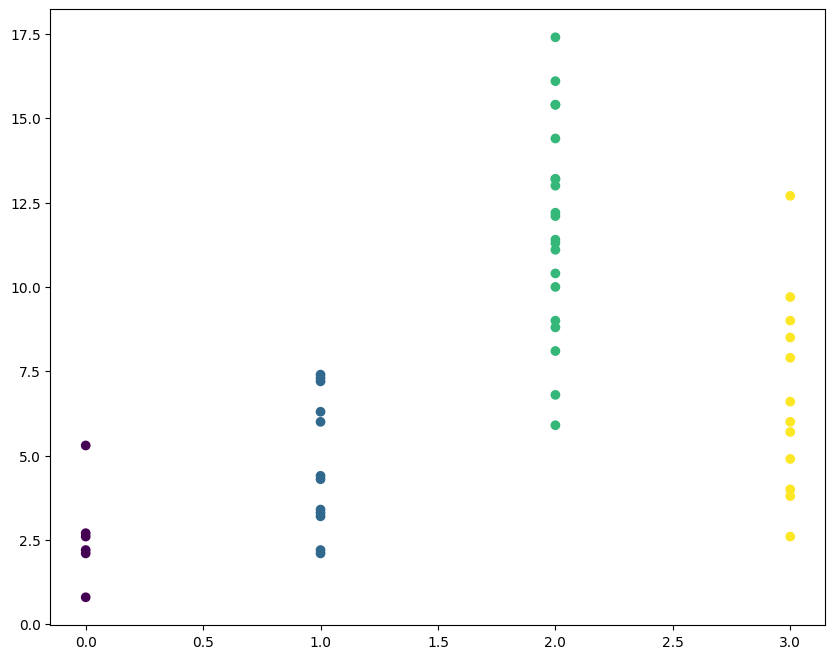

In [45]:
# Plot Clusters
plt.figure(figsize=(10, 8))  
plt.scatter(df2['clustersid'],df2['Murder'], c=hclusters.labels_) 